<a href="https://colab.research.google.com/github/Harsha1479/Harsh/blob/main/StatsProject2_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [107]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load the dataset
import pandas as pd
df=pd.read_csv('/content/Superstore.csv',encoding='latin1')


# Display the first few rows and summary statistics
print(df.head())
print(df.info())
print(df.describe())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2013-152156  09-11-2013  12-11-2013    Second Class    CG-12520   
1       2  CA-2013-152156  09-11-2013  12-11-2013    Second Class    CG-12520   
2       3  CA-2013-138688  13-06-2013  17-06-2013    Second Class    DV-13045   
3       4  US-2012-108966  11-10-2012  18-10-2012  Standard Class    SO-20335   
4       5  US-2012-108966  11-10-2012  18-10-2012  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [97]:

# Handle missing values
print(df.isnull())

# Convert data types if necessary
print(df.dtypes)
# Create any new columns needed for analysis



      Row ID  Order ID  Order Date  Ship Date  Ship Mode  Customer ID  \
0      False     False       False      False      False        False   
1      False     False       False      False      False        False   
2      False     False       False      False      False        False   
3      False     False       False      False      False        False   
4      False     False       False      False      False        False   
...      ...       ...         ...        ...        ...          ...   
9989   False     False       False      False      False        False   
9990   False     False       False      False      False        False   
9991   False     False       False      False      False        False   
9992   False     False       False      False      False        False   
9993   False     False       False      False      False        False   

      Customer Name  Segment  Country   City  ...  Postal Code  Region  \
0             False    False    False  False  ...

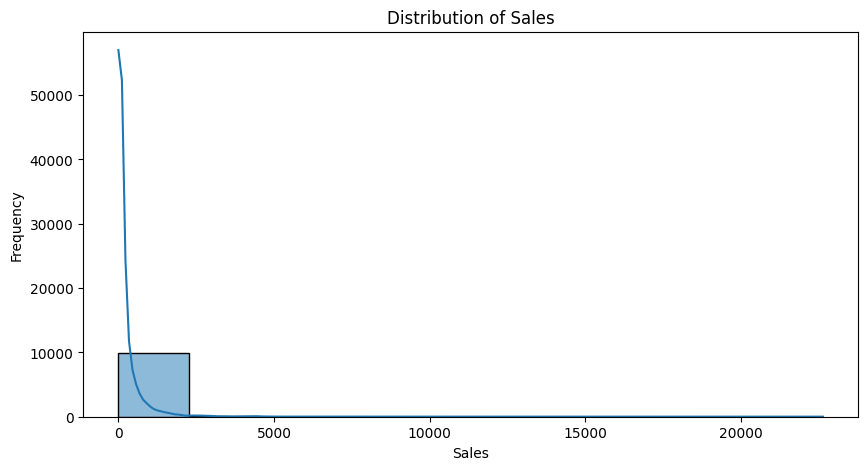

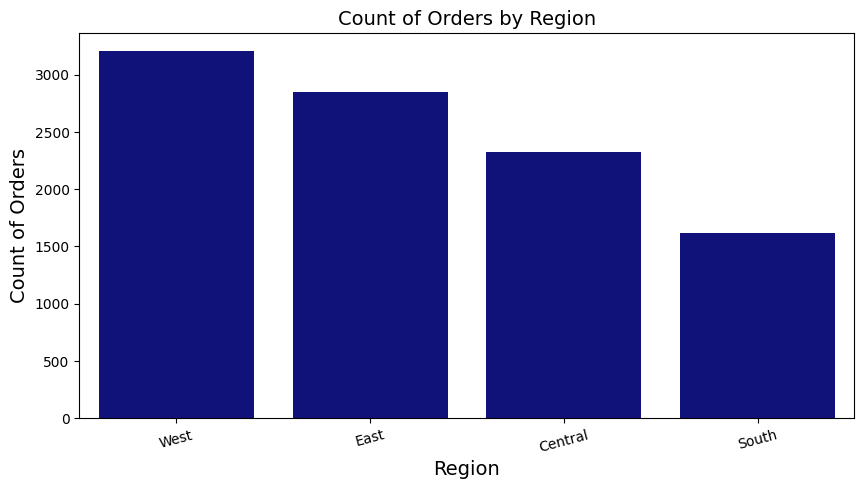

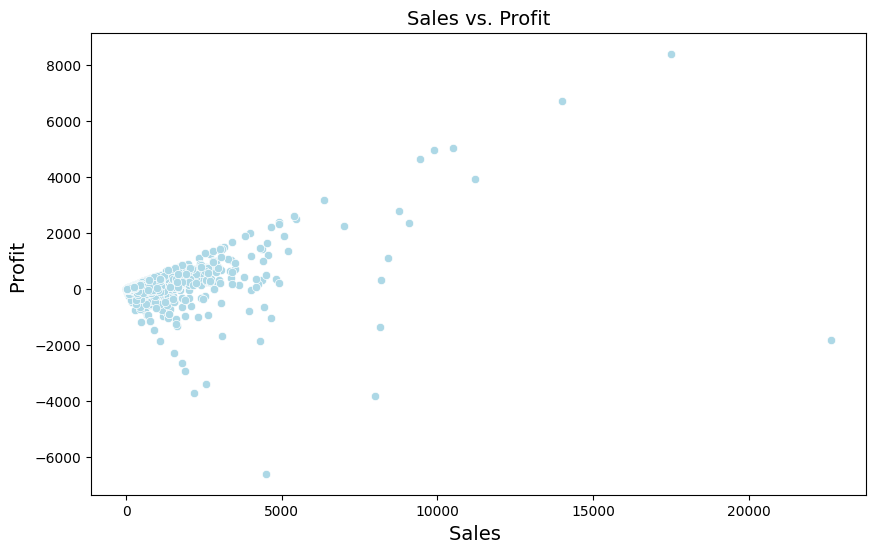

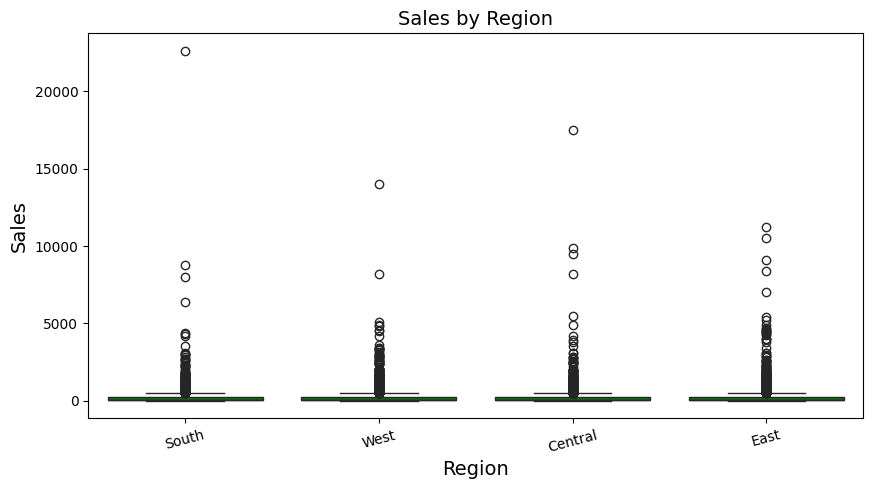

In [98]:
# Univariate analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms for 'Sales' and 'Profit'
plt.figure(figsize=(10, 5))
sns.histplot(df['Sales'], bins=10, kde=True )
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

# orders by region
region_order_count = df['Region'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=region_order_count.index, y=region_order_count.values, color="darkblue")
plt.title('Count of Orders by Region', fontsize=14)
plt.xlabel('Region', fontsize=14)
plt.ylabel('Count of Orders', fontsize=14)
plt.xticks(rotation=15)
plt.show()


# Sales vs. Profit
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales', y='Profit', color='lightblue')
plt.title('Sales vs. Profit', fontsize=14)
plt.xlabel('Sales ', fontsize=14)
plt.ylabel('Profit ', fontsize=14)
plt.show()

#by Region
plt.figure(figsize=(10, 5))
sns.boxplot(x='Region', y='Sales', data=df, color='green')
plt.title("Sales by Region", fontsize=14)
plt.xlabel("Region", fontsize=14)
plt.ylabel("Sales", fontsize=14)
plt.xticks(rotation=15)
plt.show()







In [99]:

# Summary statistics for numerical variables
numerical_stats = df.describe()
print("Summary statistics for numerical variables:\n")
print(numerical_stats)


# Grouping by 'Category' and calculating summary statistics for 'Sales' and 'Profit'
grouped_stats_category =df.groupby('Category')[['Sales', 'Profit']].agg(['mean', 'sum', 'count', 'min', 'max'])

# Display the grouped statistics for category
print("Grouped statistics by Category:\n")
print(grouped_stats_category)






Summary statistics for numerical variables:

            Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit  
count  9994.000000  
mean     28.656896  
std     234.260108  
min   -6599.978000  
25%       1.728750  
50%       8.666500  
75%      29.364000  
max    8399.976000  
Grouped statistics by Category:

                      Sales                     


### Conclusion

- Summary of key findings.
- Insights based on the analysis.



## Additional Statistical Analysis


In [101]:


import scipy.stats as stats


# Perform the T-test for sales in different regions

region_sales = df.groupby('Region')['Sales'].mean()


region_east = df[df['Region'] == 'East']['Sales']
region_west = df[df['Region'] == 'West']['Sales']

t_stat, p_value = stats.ttest_ind(region_east, region_west)


print(f"T-test: T-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

contingency_table = pd.crosstab(df['Ship Mode'], df['Segment'])
chi2_stat, chi2_p_value, dof, expected = stats.chi2_contingency(contingency_table)


print(f"Chi-square test: chi2 = {chi2_stat:.4f}, p-value = {chi2_p_value:.4f}" , f"dof = {dof}")






# Example: Chi-square test for independence between Ship Mode and Customer Segment





T-test: T-statistic = 0.8039, p-value = 0.4215
Chi-square test: chi2 = 28.0979, p-value = 0.0001 dof = 6


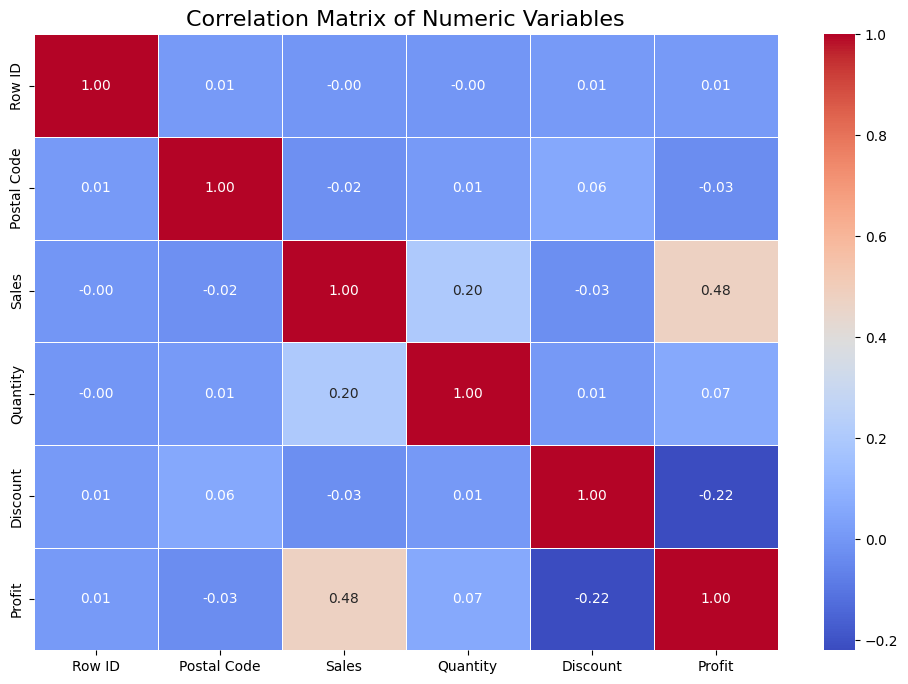

In [105]:
# Selecting only numeric columns for correlation matrix



numeric_columns = df.select_dtypes(include=['number'])
correlation_matrix = numeric_columns.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Variables', fontsize=16)
plt.show()






In [111]:

# Plotting sales trends over time
# Resample sales data by month

sales_trends = df.groupby('Year-Month')['Sales'].sum()
plt.figure(figsize=(10, 5))
sales_trends.plot(kind='line', color='yellow', marker='o', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Year-Month', fontsize=14)
plt.ylabel('Sales', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



KeyError: 'Year-Month'

In [113]:

# Plotting profit trends over time

profit_trends = df.groupby('Year-Month')['Profit'].sum()
plt.figure(figsize=(12, 6))
profit_trends.plot(kind='line', color='green', marker='o', linewidth=2)
plt.title('Monthly Profit Trend', fontsize=16)
plt.xlabel('Year-Month', fontsize=14)
plt.ylabel('Profit', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()





KeyError: 'Year-Month'

Top categories by total sales:
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Top categories by total profit:
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


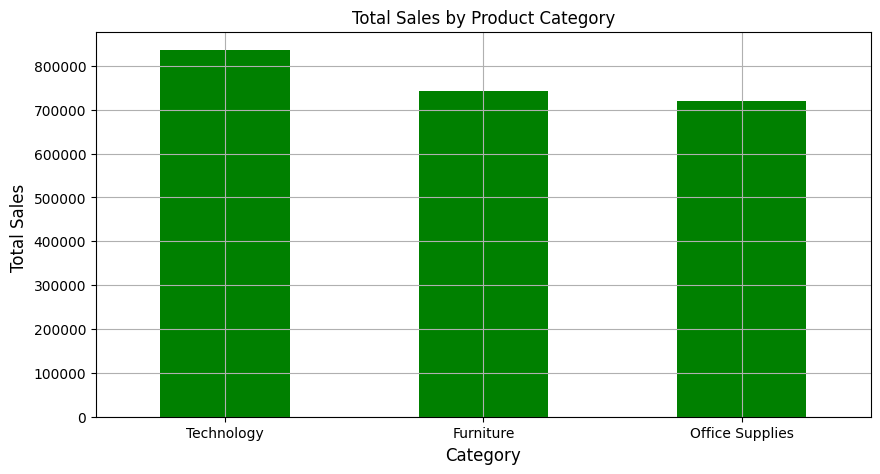

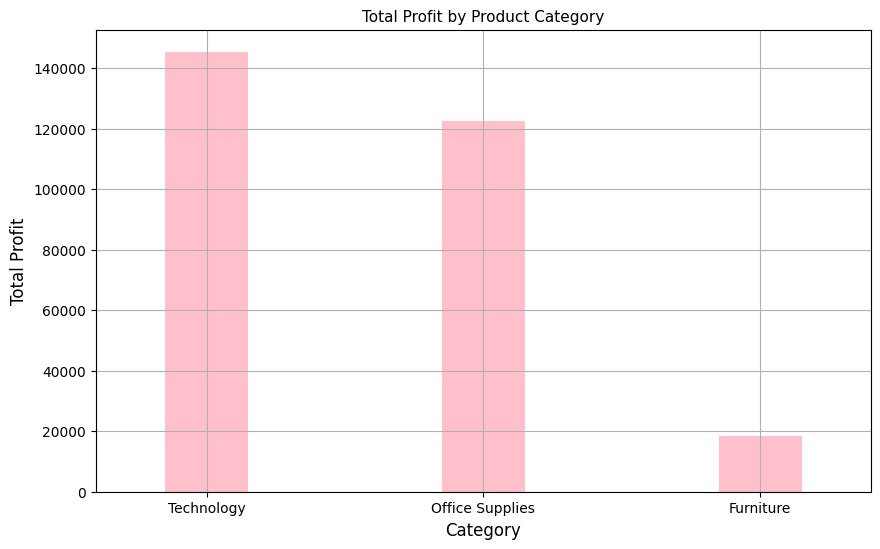

In [114]:

# Identifying top-performing product categories based on total sales and profit
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print("Top categories by total sales:")
print(category_sales)
print("\nTop categories by total profit:")
print(category_profit)
# Plotting total sales by product category
plt.figure(figsize=(10, 5))
category_sales.plot(kind='bar', color='green', width=0.5)
plt.title('Total Sales by Product Category', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ', fontsize=12)
plt.xticks(rotation=0)
plt.grid(True)
plt.show()






# Plotting total profit by product category


plt.figure(figsize=(10, 6))
category_profit.plot(kind='bar', color='pink', width=0.3)
plt.title('Total Profit by Product Category', fontsize=11)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)
plt.xticks(rotation=0)
plt.grid(True)
plt.show()








In [90]:

# Generating summary statistics for each region
region_summary = df.groupby('Region').agg({
    'Sales': ['mean', 'median', 'std', 'sum'],
    'Profit': ['mean', 'median', 'std', 'sum'],
    'Quantity': ['mean', 'median', 'std', 'sum']
})
# Display summary statistics


print(region_summary)


              Sales                                      Profit           \
               mean  median         std          sum       mean   median   
Region                                                                     
Central  215.772661  45.980  632.779010  501239.8908  17.092709   5.1840   
East     238.336110  54.900  620.712652  678781.2400  32.135808   8.1717   
South    241.803645  54.594  774.796273  391721.9050  28.857673   9.0720   
West     226.493233  60.840  524.876877  725457.8245  33.849032  11.1664   

                                  Quantity                          
                std          sum      mean median       std    sum  
Region                                                              
Central  291.487465   39706.3625  3.779595    3.0  2.160561   8780  
East     251.605084   91522.7800  3.728230    3.0  2.221779  10618  
South    212.893088   46749.4303  3.832716    3.0  2.249379   6209  
West     174.109081  108418.4489  3.829535    3.0  2.

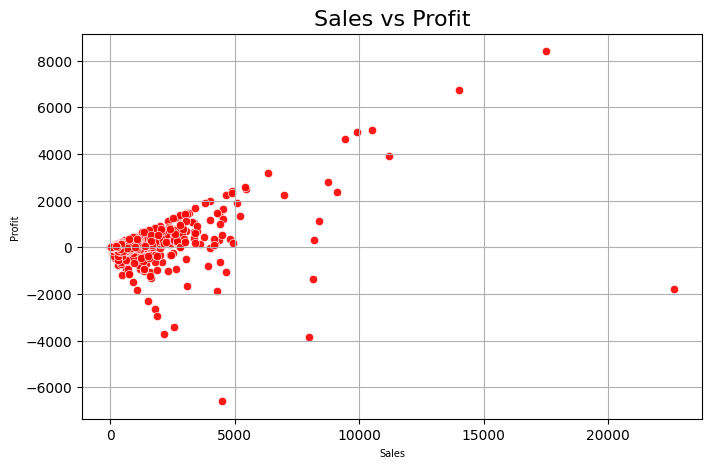

Correlation between Sales and Profit: 0.4791


In [91]:

# Visualizing the correlation between sales and profit

correlation_coefficient = df[['Sales', 'Profit']].corr().iloc[0, 1]
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Sales', y='Profit', color='red', alpha=0.9)
plt.title('Sales vs Profit', fontsize=16)
plt.xlabel('Sales', fontsize=7)
plt.ylabel('Profit', fontsize=7)
plt.grid(True)
plt.show()


# Displaying the correlation coefficient
print(f"Correlation between Sales and Profit: {correlation_coefficient:.4f}")




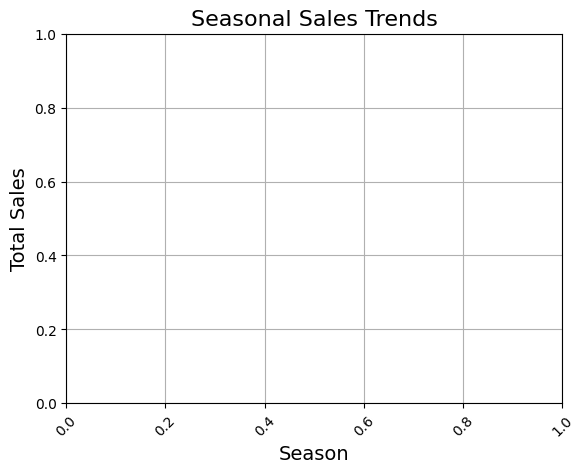

In [122]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

plt.title('Seasonal Sales Trends', fontsize=16)
plt.xlabel('Season', fontsize=14)
plt.ylabel('Total Sales', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()








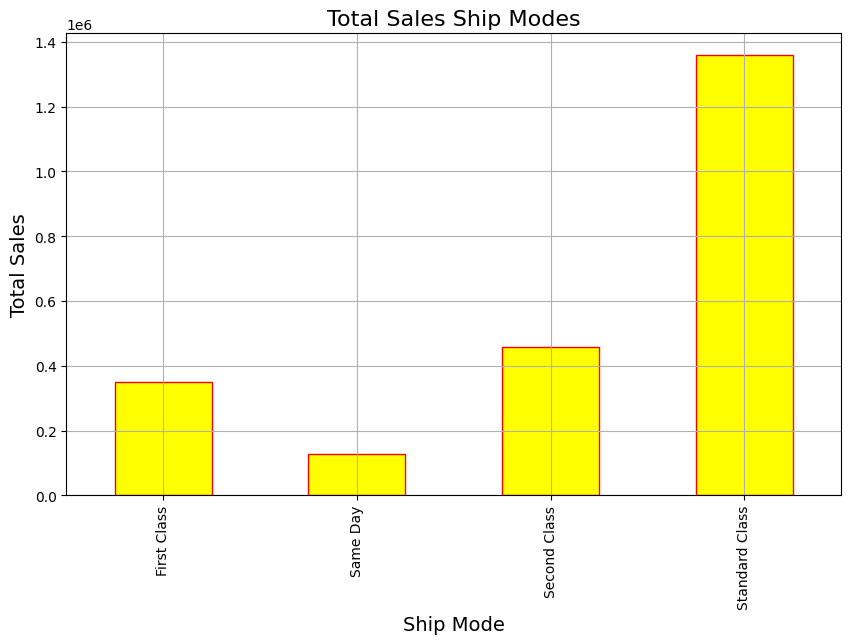


Ship Modes:
First Class: 351,428.42
Same Day: 128,363.12
Second Class: 459,193.57
Standard Class: 1,358,215.74


,Sales
Ship Mode,
First Class,3.514284e+05
Same Day,1.283631e+05
Second Class,4.591936e+05
Standard Class,1.358216e+06


In [123]:

# Comparing sales across different ship modes

sales_by_ship_mode = df.groupby('Ship Mode')['Sales'].sum()
plt.figure(figsize=(10, 6))
sales_by_ship_mode.plot(kind='bar', color='yellow', edgecolor='red')
plt.title('Total Sales Ship Modes', fontsize=16)
plt.xlabel('Ship Mode', fontsize=14)
plt.ylabel('Total Sales', fontsize=14)
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

print("\nShip Modes:")
for ship_mode, total_sales in sales_by_ship_mode.items():
    print(f"{ship_mode}: {total_sales:,.2f}")




sales_by_ship_mode


Column names after cleaning:
Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')


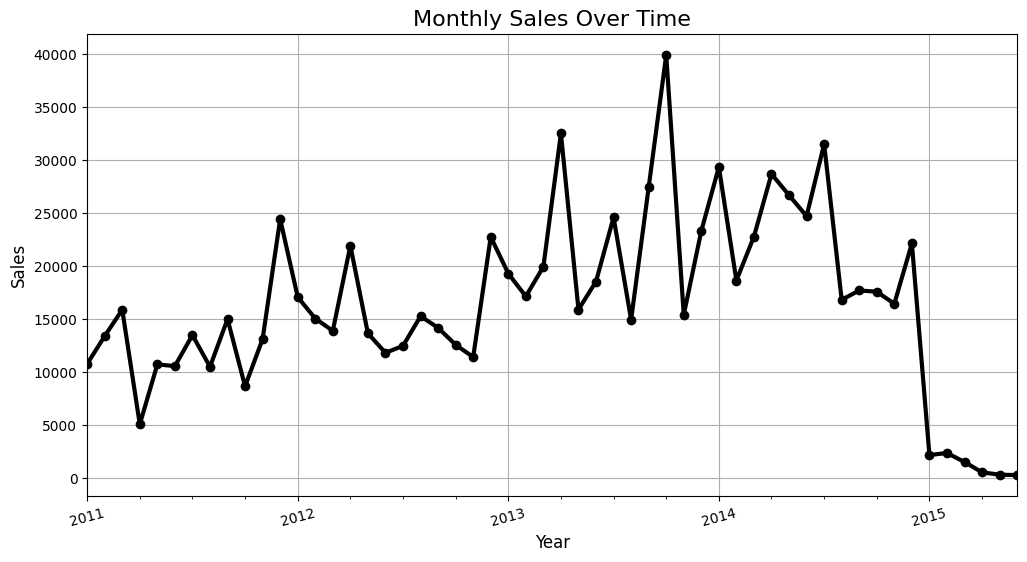

In [95]:
# Ensure column names are clean
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Print column names to verify
print("Column names after cleaning:")
print(df.columns)

# Ensure 'Ship Date' column is datetime type
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')

# Dropping rows where 'Ship Date' couldn't be converted
df.dropna(subset=['ship_date'], inplace=True)

# Resample sales data by month

df['year_month'] = df['ship_date'].dt.to_period('M')
sales_by_month = df.groupby('year_month')['sales'].sum()
plt.figure(figsize=(12, 6))
sales_by_month.plot(kind='line', color='black', marker='o', linewidth=3)
plt.title('Monthly Sales Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.xticks(rotation=15)
plt.grid(True)
plt.show()









